# préparation et extraction de features

In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import seaborn as sns

# Importation des outils scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score

from radios_dataset import RadiosDataset

In [2]:
# Détecte si tu on a une carte graphique Nvidia (cuda) ou Apple Silicon (mps), sinon reste sur cpu
# Dans mes tests passer du cpu au gpu (plus 4 workers dans le DataLoader,et pin_memory=True) fait gagner un facteur 18 sur le temps d'extraction des features !
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Calculs exécutés sur : {device}")

Calculs exécutés sur : cuda


In [3]:
def extraire_images(path):
    """ renvoie un tableau numpy contenant les images extraites du chemin donné """
    path_fichier_jpg = list(path.glob("*.jpg"))
    return np.array([np.array(Image.open(fichier)) for fichier in path_fichier_jpg])

In [4]:
def extraire_features(modele, dataloader):
    liste_features = []
    
    with torch.no_grad():
        for batch_images in tqdm(dataloader, desc="Extraction des features"):
            
            # On envoie le lot d'images sur la carte graphique (là où se trouve ResNet)
            batch_images = batch_images.to(device)
            
            # On extrait les vecteurs
            features = modele(batch_images)
            
            # On ramène le résultat sur le CPU de l'ordinateur avant de le sauvegarder.
            # ça soulage la carte graphique
            liste_features.append(features.cpu())
            
    # On empile tout à la fin
    features_finales = torch.cat(liste_features, dim=0)
    return features_finales

In [5]:

# On définit les chemins
chemin_sans_label = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/sans_label")
chemin_normal = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/normal")
chemin_cancer = Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/cancer")

chemins_sans_label = list(Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/sans_label").glob("*.jpg"))
chemins_normal = list(Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/normal").glob("*.jpg"))
chemins_cancer = list(Path("/home/arnaud/Code/Projet10/mri_dataset_brain_cancer_oc/avec_labels/cancer").glob("*.jpg"))

print(f"Nombre d'images sans label : {len(chemins_sans_label)}")
print(f"Nombre d'images normales : {len(chemins_normal)}")
print(f"Nombre d'images cancéreuses : {len(chemins_cancer)}")

# On récupère tous les fichiers png
images_sans_label = extraire_images(chemin_sans_label)
images_normal = extraire_images(chemin_normal)
images_cancer = extraire_images(chemin_cancer)

if len(images_sans_label) == 0 or len(images_normal) == 0 or len(images_cancer) == 0:
    print("Erreur : Aucun fichier trouvé dans l'un des dossiers.")

else:
    print(f"Succès : {len(images_sans_label)} images trouvées.")
    # On peut maintenant prendre la première en toute sécurité
    image_matrice = np.array(images_sans_label[0])     
    print(f"Forme de l'image : {image_matrice.shape}")


Nombre d'images sans label : 1406
Nombre d'images normales : 50
Nombre d'images cancéreuses : 50
Succès : 1406 images trouvées.
Forme de l'image : (512, 512, 3)


In [6]:
def verifier_format_images(images):
    """ verifie que toutes les images ont la même taille et le même nombre de canaux de couleur de base (512x512 pixels et 3 canaux) """
    memedimensions = True
    # On vérifie que toutes les images sont au même format
    for image in images:
        memeDimensions = True
        if np.array(image).shape != (512, 512, 3):
            print(f"Attention : L'image {image} a une taille différente : {image.size}")
            memedimensions = False
    if memedimensions:
        print("Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.")
    else:
        print("Il y a des images avec des tailles différentes. Veuillez vérifier les fichiers.")
    return memedimensions


In [7]:
# On vérifie que toutes les images sont bien au même format

verifier_format_images(images_sans_label)
verifier_format_images(images_normal)
verifier_format_images(images_cancer)

Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.
Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.
Toutes les images ont la même taille : 512x512 pixels et 3 canaux de couleur.


True

In [8]:
# Tailles de nos ensembles 
print(f"Nombre d'images sans label : {len(images_sans_label)}")
print(f"Nombre d'images normales : {len(images_normal)}")
print(f"Nombre d'images cancéreuses : {len(images_cancer)}")

Nombre d'images sans label : 1406
Nombre d'images normales : 50
Nombre d'images cancéreuses : 50


In [9]:
# Vérifications pour trouver des outliers
# -> On regroupe tout dans une même liste pour faire les vérifications d'un coup
toutes_les_images = np.concatenate([images_sans_label, images_normal, images_cancer])

# 1. On calcule la moyenne de CHAQUE image (le résultat sera une liste de 1506 moyennes)
moyennes_par_image = np.mean(toutes_les_images, axis=(1, 2, 3))

# 2. On calcule la moyenne et l'écart-type de ces 1506 valeurs
moyenne_des_moyennes = np.mean(moyennes_par_image)
ecart_type = np.std(moyennes_par_image)

print(f"Moyenne globale : {moyenne_des_moyennes}")
print(f"Écart-type global : {ecart_type}")

# 3. On calcule le "Z-score" (à combien d'écarts-types chaque image se trouve de la moyenne)
z_scores = np.abs((moyennes_par_image - moyenne_des_moyennes) / ecart_type)

# 4. On trouve les index des images qui dépassent le seuil de 3
index_outliers = np.where(z_scores > 3)[0]

print(f"Nombre d'outliers potentiels trouvés : {len(index_outliers)}")

Moyenne globale : 52.400531632861195
Écart-type global : 17.373623445055856
Nombre d'outliers potentiels trouvés : 14


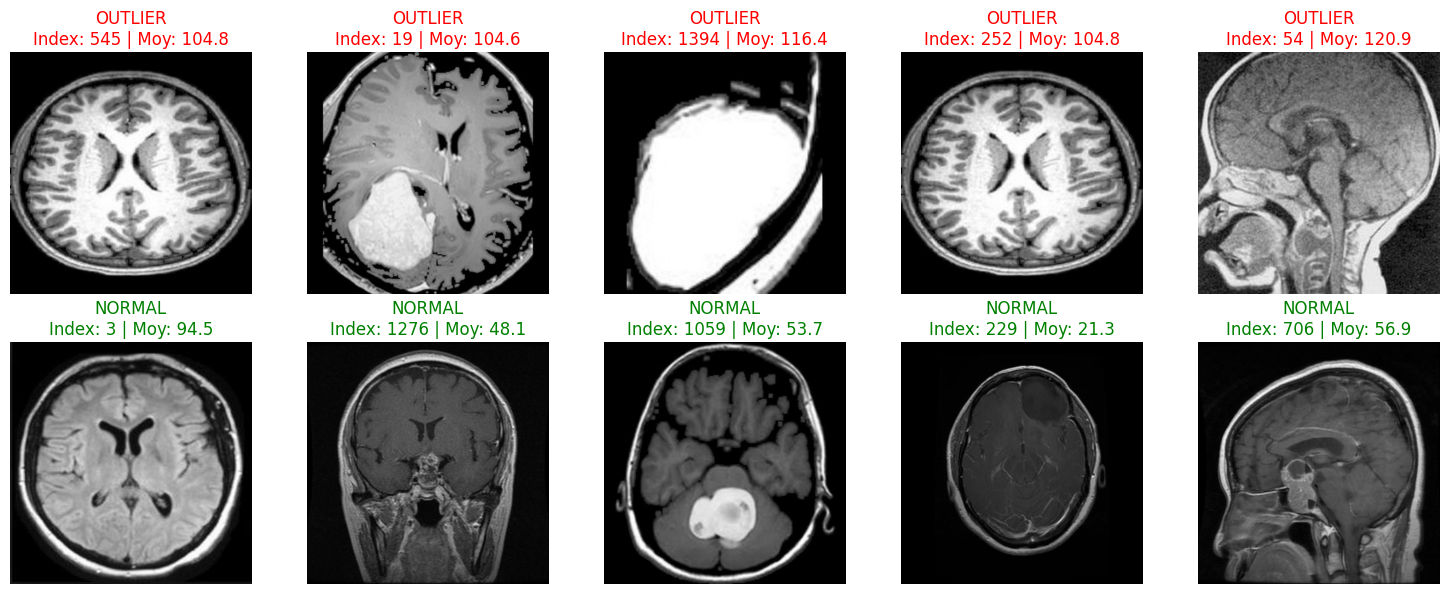

In [10]:
import matplotlib.pyplot as plt
import random

# 1. On liste tous les index "normaux" (ceux qui ne sont PAS dans tes 14 outliers)
tous_les_index = np.arange(len(toutes_les_images))
index_normaux = np.setdiff1d(tous_les_index, index_outliers)

# 2. On sélectionne un échantillon au hasard (ex: 5 images de chaque)
nb_a_afficher = 5
echantillon_outliers = random.sample(list(index_outliers), nb_a_afficher)
echantillon_normaux = random.sample(list(index_normaux), nb_a_afficher)

# 3. Création de la figure (2 lignes, 5 colonnes)
fig, axes = plt.subplots(nrows=2, ncols=nb_a_afficher, figsize=(15, 6))

# ---- LIGNE 1 : Affichage des Outliers ----
for i, idx in enumerate(echantillon_outliers):
    ax = axes[0, i]
    # On affiche l'image (si tes images sont en niveaux de gris, ajoute cmap='gray')
    ax.imshow(toutes_les_images[idx]) 
    
    # On ajoute un titre avec la valeur de la moyenne pour comprendre pourquoi c'est un outlier
    moyenne_img = moyennes_par_image[idx]
    ax.set_title(f"OUTLIER\nIndex: {idx} | Moy: {moyenne_img:.1f}", color='red')
    ax.axis('off') # On cache les axes (les graduations de pixels)

# ---- LIGNE 2 : Affichage des Normales ----
for i, idx in enumerate(echantillon_normaux):
    ax = axes[1, i]
    ax.imshow(toutes_les_images[idx])
    
    moyenne_img = moyennes_par_image[idx]
    ax.set_title(f"NORMAL\nIndex: {idx} | Moy: {moyenne_img:.1f}", color='green')
    ax.axis('off')

# Ajustement esthétique pour ne pas que les titres se chevauchent
plt.tight_layout()
plt.show()

Les outliers n'ont pas l'air d'être des erreurs mais juste des images plus clairs (peut-être due à un autre système d'imagerie ?)

# Clustering non supervisé

In [11]:
# def preparer_extracteur(nom_modele, device):
#     print(f"Préparation de l'extracteur : {nom_modele.upper()}...")
    
#     if nom_modele == "resnet50":
#         poids = models.ResNet50_Weights.DEFAULT
#         modele = models.resnet50(weights=poids)
#         modele.fc = nn.Identity()
        
#     elif nom_modele == "densenet121":
#         poids = models.DenseNet121_Weights.DEFAULT
#         modele = models.densenet121(weights=poids)
#         modele.classifier = nn.Identity()
        
#     elif nom_modele == "inception_v3":
#         poids = models.Inception_V3_Weights.DEFAULT
#         modele = models.inception_v3(weights=poids)
#         modele.fc = nn.Identity()
        
#     else:
#         raise ValueError("Modèle non reconnu.")

#     modele.eval() 
#     modele = modele.to(device)

#     pipeline = poids.transforms()
    
#     return modele, pipeline

In [12]:
def preparer_extracteur(nom_modele, device):
    print(f"Préparation de l'extracteur : {nom_modele.upper()}...")
    
    if nom_modele == "resnet50":
        modele = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modele.fc = nn.Identity()
        taille_image = 512        
        
    elif nom_modele == "densenet121":
        modele = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        modele.classifier = nn.Identity()
        taille_image = 512
        
    elif nom_modele == "inception_v3":
        modele = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        modele.fc = nn.Identity()
        taille_image = 299 
        
    else:
        raise ValueError("Modèle non reconnu.")

    modele.eval()
    modele = modele.to(device)
    
    # --- LE PIPELINE CORRIGÉ ---
    liste_transformations = []
    
    if taille_image != 512:
        liste_transformations.append(transforms.Resize((taille_image, taille_image)))
        
    liste_transformations.extend([
        transforms.ToTensor(),
        # La ligne Lambda a été supprimée ici !
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    pipeline = transforms.Compose(liste_transformations)
    
    return modele, pipeline

In [13]:
def extract_features(modele, transformer):
    # 1. On crée les "recettes" pour tes trois dossiers
    dataset_sans_label = RadiosDataset(chemins_images=chemins_sans_label, transformations=transformer)
    dataset_normal = RadiosDataset(chemins_images=chemins_normal, transformations=transformer)
    dataset_cancer = RadiosDataset(chemins_images=chemins_cancer, transformations=transformer)

    BATCH_SIZE = 128

    # 2. On crée les DataLoaders

    dataloader_sans_label = DataLoader(dataset_sans_label, batch_size=BATCH_SIZE, shuffle=False, 
        num_workers=4, 
        pin_memory=True)
    dataloader_normal = DataLoader(dataset_normal, batch_size=BATCH_SIZE, shuffle=False, 
        num_workers=4, 
        pin_memory=True)
    dataloader_cancer = DataLoader(dataset_cancer, batch_size=BATCH_SIZE, shuffle=False, 
        num_workers=4, 
        pin_memory=True)


    # On lance l'extraction !
    print("Extraction des features sans label...")
    features_sans_label = extraire_features(modele, dataloader_sans_label)

    print("Extraction des features normal...")
    features_normal = extraire_features(modele, dataloader_normal)

    print("Extraction des features cancer...")
    features_cancer = extraire_features(modele, dataloader_cancer)

    print("Taille finale des features :", features_sans_label.shape)

    return {
        "sans_label": features_sans_label,
        "normal": features_normal,
        "cancer": features_cancer
    }

In [14]:
resnet50, transformations_resnet = preparer_extracteur("resnet50", device)
densenet121, transformations_densenet = preparer_extracteur("densenet121", device)
inception_v3, transformations_inception = preparer_extracteur("inception_v3", device)

dict_features = {
    "resnet50": {"model": resnet50, "features" : extract_features(resnet50, transformations_resnet)},
    "densenet121": {"model": densenet121, "features" : extract_features(densenet121, transformations_densenet)},
    "inception_v3": {"model": inception_v3, "features" : extract_features(inception_v3, transformations_inception)}
}


Préparation de l'extracteur : RESNET50...
Préparation de l'extracteur : DENSENET121...
Préparation de l'extracteur : INCEPTION_V3...
Extraction des features sans label...


Extraction des features:   0%|          | 0/11 [00:00<?, ?it/s]

Extraction des features normal...


Extraction des features:   0%|          | 0/1 [00:00<?, ?it/s]

Extraction des features cancer...


...

Extraction des features normal...


Extraction des features:   0%|          | 0/1 [00:00<?, ?it/s]

Extraction des features cancer...


Extraction des features:   0%|          | 0/1 [00:00<?, ?it/s]

Taille finale des features : torch.Size([1406, 2048])


In [15]:
def entrainer_pipeline_clustering(features_tensor, n_clusters=2):
    print("Démarrage du pipeline de clustering...")
    
    # 1. Conversion en NumPy
    if torch.is_tensor(features_tensor):
        features_np = features_tensor.numpy()
    else:
        features_np = features_tensor
        
    # 2. Standardisation
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_np)
    
    # 3. Réduction intermédiaire (PCA 50)
    pca_50 = PCA(n_components=50, random_state=42)
    features_50d = pca_50.fit_transform(features_scaled)
    
    # 4. Apprentissage des Labels Faibles (K-Means)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    labels_faibles = kmeans.fit_predict(features_50d)
    
    # 5. Réduction Visuelle (t-SNE 2D)
    print("Calcul du t-SNE en cours (cela peut prendre quelques secondes)...")
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features_50d)
    
    print("Pipeline terminé !")
    
    return {
        "scaler": scaler,
        "pca": pca_50,
        "kmeans": kmeans,
        "labels_faibles": labels_faibles,
        "coordonnees_2d": features_2d
    }

In [16]:
def afficher_tsne(coordonnees_2d, labels, titre="Clustering t-SNE"):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=coordonnees_2d[:, 0], 
        y=coordonnees_2d[:, 1], 
        hue=labels, 
        palette=['#1f77b4', '#ff7f0e'],
        alpha=0.7
    )
    plt.title(titre)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(title='Labels')
    plt.show()

In [17]:
def evaluer_score_ari(features_normal, features_cancer, outils_clustering):
    # 1. Sécurité : on s'assure d'avoir du NumPy
    feat_norm_np = features_normal.numpy() if torch.is_tensor(features_normal) else features_normal
    feat_canc_np = features_cancer.numpy() if torch.is_tensor(features_cancer) else features_cancer
    
    # On rassemble les données de test
    features_test = np.concatenate((feat_norm_np, feat_canc_np), axis=0)
    
    # On crée la vérité terrain (0 = Normal, 1 = Cancer)
    vrais_labels = np.concatenate((
        np.zeros(len(feat_norm_np)), 
        np.ones(len(feat_canc_np))
    ))

    # 2. On déballe notre boîte à outils (déjà entraînée sur le sans label)
    scaler = outils_clustering["scaler"]
    pca_50 = outils_clustering["pca"]
    kmeans = outils_clustering["kmeans"]

    # 3.transform et predict UNIQUEMENT pas fit transform
    features_test_scaled = scaler.transform(features_test)
    features_test_50d = pca_50.transform(features_test_scaled)
    predictions_test = kmeans.predict(features_test_50d)

    # 4. Le Verdict
    score_ari = adjusted_rand_score(vrais_labels, predictions_test)
    return score_ari


🚀 ANALYSE DU MODÈLE : RESNET50
Démarrage du pipeline de clustering...
Calcul du t-SNE en cours (cela peut prendre quelques secondes)...
Pipeline terminé !


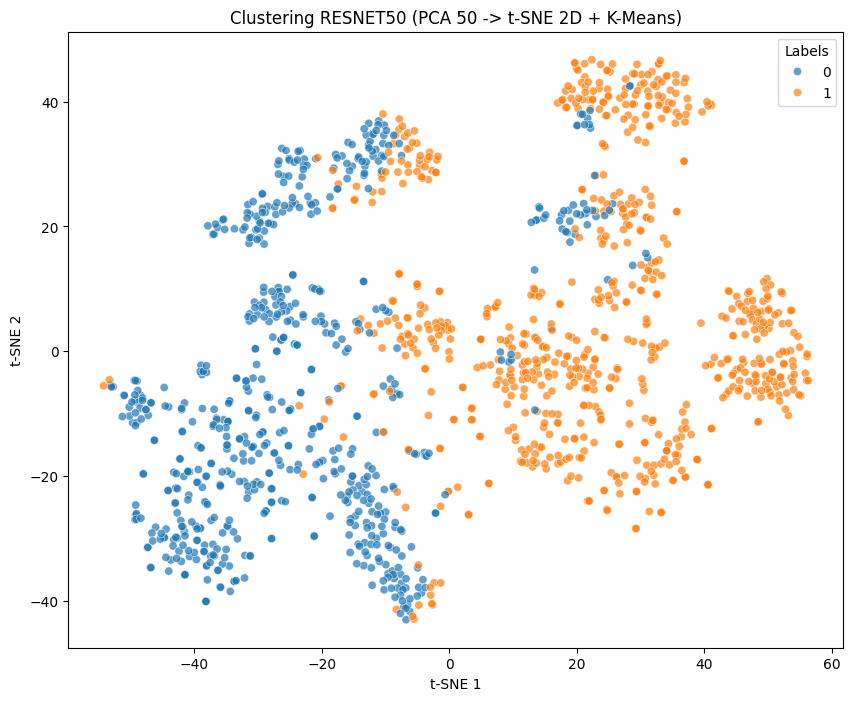

🏆 Score ARI pour RESNET50 : 0.2642

🚀 ANALYSE DU MODÈLE : DENSENET121
Démarrage du pipeline de clustering...
Calcul du t-SNE en cours (cela peut prendre quelques secondes)...
Pipeline terminé !


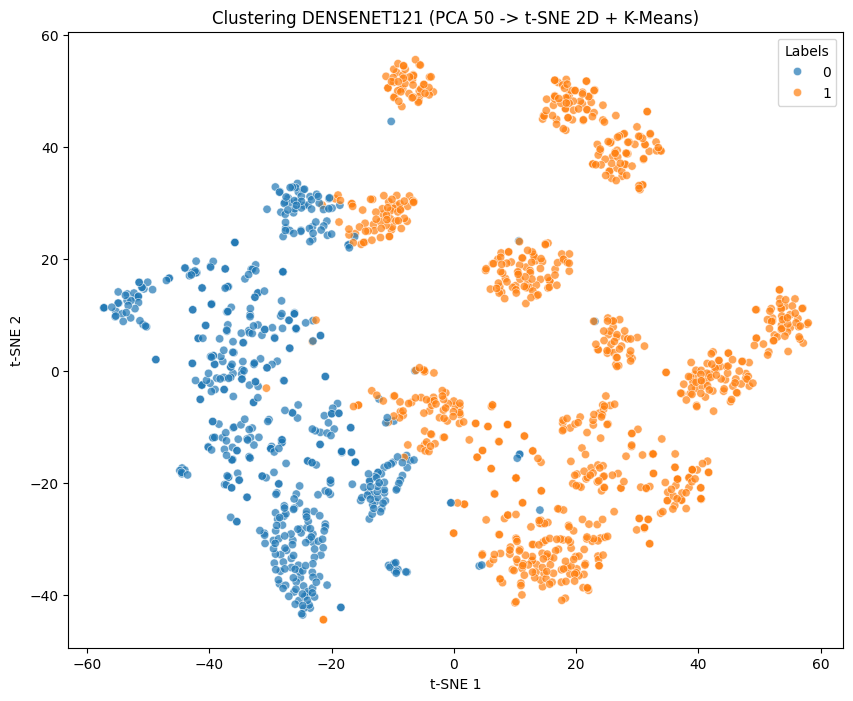

🏆 Score ARI pour DENSENET121 : 0.5734

🚀 ANALYSE DU MODÈLE : INCEPTION_V3
Démarrage du pipeline de clustering...
Calcul du t-SNE en cours (cela peut prendre quelques secondes)...
Pipeline terminé !


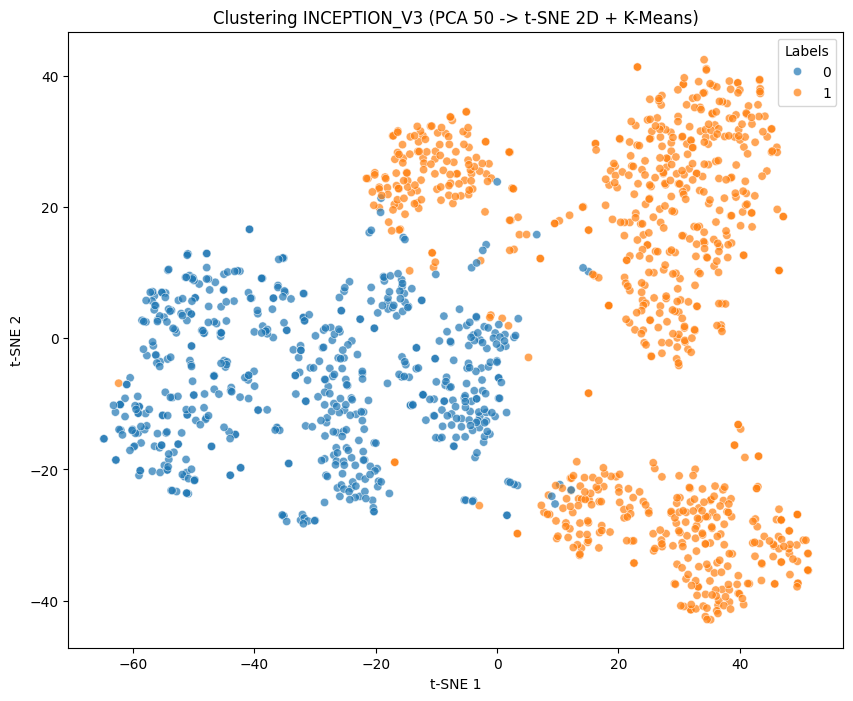

🏆 Score ARI pour INCEPTION_V3 : 0.4041

=== CLASSEMENT FINAL ARI ===
DENSENET121     : 0.5734
INCEPTION_V3    : 0.4041
RESNET50        : 0.2642


In [18]:
# Un petit dictionnaire pour stocker le palmarès final
scores_finaux = {}
resultats = {}

for nom_modele, data in dict_features.items():
    print(f"\n{'='*50}")
    print(f"🚀 ANALYSE DU MODÈLE : {nom_modele.upper()}")
    print(f"{'='*50}")
    
    # 1. On entraîne le K-Means
    features_sl = data["features"]["sans_label"]
    resultats_clustering = entrainer_pipeline_clustering(features_sl)
    resultats[nom_modele] = resultats_clustering
    # 2. On affiche le graphique t-SNE pour voir le comportement du modèle
    afficher_tsne(
        coordonnees_2d=resultats_clustering["coordonnees_2d"], 
        labels=resultats_clustering["labels_faibles"], 
        titre=f"Clustering {nom_modele.upper()} (PCA 50 -> t-SNE 2D + K-Means)"
    )
    
    # 3. On passe l'examen final (Le score ARI) avec les données labellisées
    features_norm = data["features"]["normal"]
    features_canc = data["features"]["cancer"]
    
    score = evaluer_score_ari(features_norm, features_canc, resultats_clustering)
    
    print(f"🏆 Score ARI pour {nom_modele.upper()} : {score:.4f}")
    scores_finaux[nom_modele] = score

# ==========================================
# LE GRAND CLASSEMENT FINAL
# ==========================================
print("\n" + "="*30)
print("=== CLASSEMENT FINAL ARI ===")
print("="*30)

# On trie les résultats du meilleur au moins bon
for modele, score in sorted(scores_finaux.items(), key=lambda x: x[1], reverse=True):
    print(f"{modele.upper():<15} : {score:.4f}")

Préparation du match : K-Means vs DBSCAN sur DenseNet121...


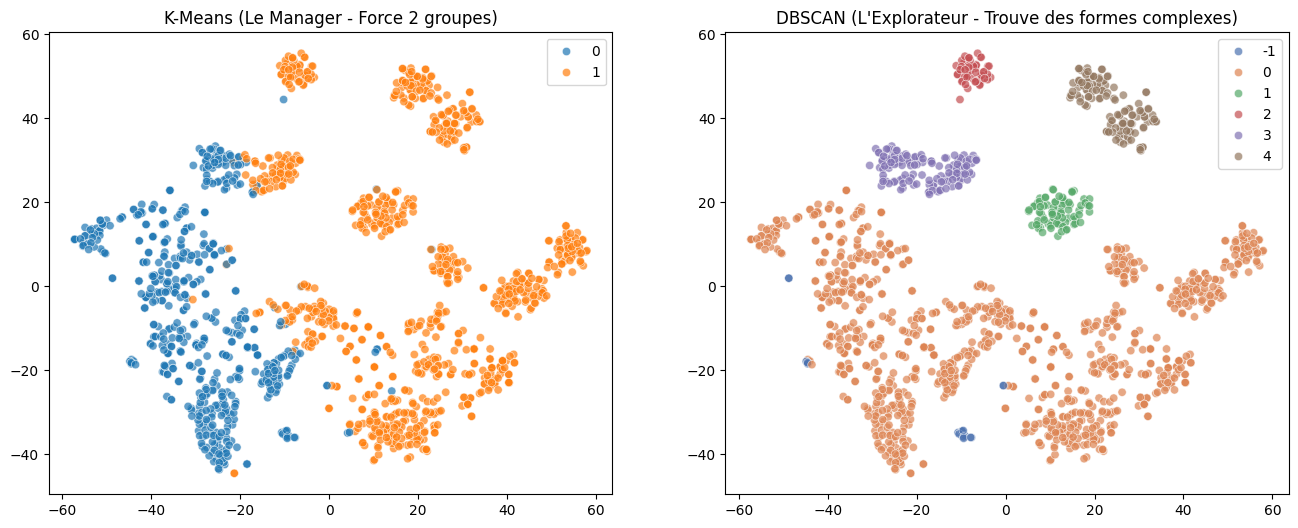


=== RÉSULTATS DU MATCH ===
🥇 Score ARI K-Means : 0.5734 (A trouvé exactement 2 groupes)
🕵️‍♂️ Bilan DBSCAN : A trouvé 5 groupes naturels et 19 images considérées comme du 'bruit' (outliers).

-> Analyse : DBSCAN n'a pas trouvé naturellement 2 groupes. L'ARI n'est pas comparable directement. C'est normal, la réalité médicale est souvent plus complexe qu'une simple séparation binaire !


In [19]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

print("Préparation du match : K-Means vs DBSCAN sur DenseNet121...")

# 1. On récupère les données de notre champion DenseNet
features_sl = dict_features["densenet121"]["features"]["sans_label"]
features_norm = dict_features["densenet121"]["features"]["normal"]
features_canc = dict_features["densenet121"]["features"]["cancer"]

# On refait le pipeline de base (Standardisation + PCA 50 + t-SNE)
resultats_densenet121 = resultats["densenet121"] # On réutilise les outils déjà entraînés
coords_2d = resultats_densenet121["coordonnees_2d"] # Nos données t-SNE !

# ==========================================
# LE CHALLENGER : DBSCAN
# ==========================================
# On l'entraîne sur les coordonnées 2D du t-SNE (plus facile pour lui)
# eps = distance max entre 2 points, min_samples = points minimum pour faire un groupe
dbscan = DBSCAN(eps=6, min_samples=15)
labels_dbscan = dbscan.fit_predict(coords_2d)

# ==========================================
# AFFICHAGE CÔTE À CÔTE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe 1 : K-Means (Le tenant du titre)
sns.scatterplot(
    x=coords_2d[:, 0], y=coords_2d[:, 1], 
    hue=resultats_densenet121["labels_faibles"], 
    palette=['#1f77b4', '#ff7f0e'], alpha=0.7, ax=axes[0]
)
axes[0].set_title("K-Means (Le Manager - Force 2 groupes)")

# Graphe 2 : DBSCAN (L'Explorateur)
# On utilise une palette dynamique car on ne sait pas combien de groupes il va trouver !
sns.scatterplot(
    x=coords_2d[:, 0], y=coords_2d[:, 1], 
    hue=labels_dbscan, 
    palette="deep", alpha=0.7, ax=axes[1]
)
axes[1].set_title("DBSCAN (L'Explorateur - Trouve des formes complexes)")

plt.show()

# ==========================================
# CALCUL DE L'ARI POUR DBSCAN
# ==========================================
# Pour K-Means, on a déjà le score
ari_kmeans = evaluer_score_ari(features_norm, features_canc, resultats_densenet121)

# Pour DBSCAN, c'est spécial : on doit le faire prédire sur les données de test
# Problème : DBSCAN de base n'a pas de fonction .predict() ! 
# En recherche, on évalue souvent DBSCAN directement sur l'ensemble complet 
# pour voir s'il sépare naturellement la donnée.
# Mais pour rester simple, disons simplement qu'on observe le nombre de clusters trouvés :

n_clusters_trouves = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_bruit = list(labels_dbscan).count(-1)

print("\n=== RÉSULTATS DU MATCH ===")
print(f"🥇 Score ARI K-Means : {ari_kmeans:.4f} (A trouvé exactement 2 groupes)")
print(f"🕵️‍♂️ Bilan DBSCAN : A trouvé {n_clusters_trouves} groupes naturels et {n_bruit} images considérées comme du 'bruit' (outliers).")

if n_clusters_trouves != 2:
    print("\n-> Analyse : DBSCAN n'a pas trouvé naturellement 2 groupes. L'ARI n'est pas comparable directement. C'est normal, la réalité médicale est souvent plus complexe qu'une simple séparation binaire !")

### Dbscan est difficilement utilisable, on ne peut pas lui dire de faire N groupes à l'inver de k-means

In [20]:
taille_image = 512

# 1. Pipeline d'Entraînement (Avec Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((taille_image, taille_image)),
    transforms.RandomHorizontalFlip(p=0.5), # 1 chance sur 2 de faire un effet miroir
    transforms.RandomRotation(degrees=15),  # Rotation aléatoire jusqu'à 15 degrés
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Pipeline de Validation/Test (Strict, sans augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((taille_image, taille_image)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [21]:
# Mise en place de la dernière couche de classification pour DenseNet121 

modele = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Pour DenseNet121, in_features est exactement égal à 1024.
nbr_connections = modele.classifier.in_features 

# 1. On fige l'intégralité du modèle (le backbone)
for param in modele.parameters():
    param.requires_grad = False

# Nouvelle couche vierge (1024 -> 2)
modele.classifier = nn.Linear(in_features=nbr_connections, out_features=2)


# 3. On met le modèle en mode ENTRAÎNEMENT
modele.train()


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [22]:
import numpy as np
from collections import Counter

# K-Means est aveugle. Quand il crée 2 groupes, il les appelle bêtement 0 et 1.

#     K-Means a peut-être décidé que 0 = Normal et 1 = Cancer.

#     MAIS il a tout autant de chances d'avoir décidé que 0 = Cancer et 1 = Normal

print("🔍 Analyse du langage de K-Means...")

kmeans = resultats_densenet121["kmeans"]
pca_50 = resultats_densenet121["pca"]
scaler = resultats_densenet121["scaler"]

# On prend les features de nos images NORMALES (vérité terrain)
features_norm = dict_features["densenet121"]["features"]["normal"]
feat_norm_np = features_norm.numpy() if torch.is_tensor(features_norm) else features_norm

# On les fait passer dans le pipeline
feat_norm_scaled = scaler.transform(feat_norm_np)
feat_norm_50d = pca_50.transform(feat_norm_scaled)

# On demande à K-Means de prédire
predictions_normales = kmeans.predict(feat_norm_50d)

# On compte : quel est le label majoritaire ?
compteur = Counter(predictions_normales)
label_k_means_pour_normal = compteur.most_common(1)[0][0]

print(f"-> K-Means utilise le label {label_k_means_pour_normal} pour dire 'NORMAL'.")

# On définit le dictionnaire de traduction pour remettre à l'endroit :
# (On veut que 0 = Normal et 1 = Cancer pour notre réseau PyTorch)
if label_k_means_pour_normal == 0:
    print("-> Tout est déjà dans le bon ordre (0=Normal, 1=Cancer) !")
    traduction = {0: 0, 1: 1}
else:
    print("-> ⚠️ K-Means a inversé les labels ! On les remet à l'endroit.")
    traduction = {1: 0, 0: 1} # Le 1 devient 0, le 0 devient 1

🔍 Analyse du langage de K-Means...
-> K-Means utilise le label 0 pour dire 'NORMAL'.
-> Tout est déjà dans le bon ordre (0=Normal, 1=Cancer) !


In [23]:
from torch.utils.data import DataLoader

# 1. Le Dataset d'Entraînement (avec Data Augmentation + Labels corrigés)
dataset_train = RadiosDataset(
    chemins_images=chemin_sans_label, 
    labels=resultats_densenet121["labels_faibles"],          
    transformations=train_transforms
)

# 2. Le Dataset de Test (Les vraies données labellisées, sans triche/augmentation)
dataset_test = RadiosDataset(
    chemins_images=chemins_normal + chemins_cancer, 
    labels=[0]*len(chemins_normal) + [1]*len(chemins_cancer), 
    transformations=test_transforms 
)

# 3. Les DataLoaders (Ils vont apporter les images par lots de 32)
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=4)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=4)

print("Les DataLoaders Supervisés sont prêts à nourrir le réseau !")

Les DataLoaders Supervisés sont prêts à nourrir le réseau !


In [26]:
import torch.optim as optim

# ==========================================
# 1. CONFIGURATION DU PROFESSEUR ET DU JUGE
# ==========================================
modele = modele.to(device)  

# Le juge : adapté pour de la classification multi-classes/binaire
critere = nn.CrossEntropyLoss()

# Le professeur : on lui donne SEULEMENT les clés de notre nouvelle couche !
# lr = Learning Rate (la taille des pas d'apprentissage)
optimizer = optim.Adam(modele.classifier.parameters(), lr=0.001)

# Nombre de fois où le modèle va voir l'intégralité des images
epochs = 5 

print("🚀 Début de l'entraînement par Transfer Learning...")

# ==========================================
# 2. LA GRANDE BOUCLE D'APPRENTISSAGE
# ==========================================
for epoch in range(epochs):
    
    # --- PHASE D'ENTRAÎNEMENT (La salle de sport) ---
    modele.train()
    loss_entrainement = 0.0
    
    for images, labels in tqdm(dataloader_train, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long) 
        
        # 1. On remet la mémoire de l'optimiseur à zéro
        optimizer.zero_grad()
        
        # 2. Prédiction (L'élève tente une réponse)
        predictions = modele(images)
        
        # 3. Calcul de la sanction (Le juge note la réponse)
        loss = critere(predictions, labels)
        
        # 4. Rétropropagation (Le professeur calcule comment corriger le cerveau)
        loss.backward()
        
        # 5. Mise à jour (On modifie physiquement les poids de la couche !)
        optimizer.step()
        
        loss_entrainement += loss.item()
        
    # --- PHASE DE VALIDATION (La salle d'examen) ---
    # On vérifie sur nos VRAIES images (Normal / Cancer) si le modèle devient intelligent
    modele.eval()
    bonnes_reponses = 0
    total_images = 0
    loss_validation = 0.0
    
    # On désactive le calcul des corrections (on gagne de la mémoire et du temps)
    with torch.no_grad():
        for images, labels in dataloader_test:

            images = images.to(device)
            labels = labels.to(device, dtype=torch.long) 
            
            predictions = modele(images)
            loss = critere(predictions, labels)
            loss_validation += loss.item()
            
            # On prend le diagnostic avec la plus haute probabilité
            _, classe_predite = torch.max(predictions, 1)
            total_images += labels.size(0)
            bonnes_reponses += (classe_predite == labels).sum().item()
            
    precision = 100 * bonnes_reponses / total_images
    
    # Affichage du bulletin de notes à la fin de l'époque
    moyenne_loss_train = loss_entrainement / len(dataloader_train)
    moyenne_loss_val = loss_validation / len(dataloader_test)
    
    print(f"📊 Epoch {epoch+1} | Loss Train: {moyenne_loss_train:.4f} | Loss Val: {moyenne_loss_val:.4f} | Précision Test: {precision:.2f}%")
    
print("🏁 Entraînement terminé ! Le modèle est prêt pour le bloc opératoire.")

🚀 Début de l'entraînement par Transfer Learning...


Epoch 1/5 [Train]:   0%|          | 0/44 [00:00<?, ?it/s]

📊 Epoch 1 | Loss Train: 0.5100 | Loss Val: 0.6933 | Précision Test: 69.00%


Epoch 2/5 [Train]:   0%|          | 0/44 [00:00<?, ?it/s]

📊 Epoch 2 | Loss Train: 0.3308 | Loss Val: 0.4259 | Précision Test: 84.00%


...

📊 Epoch 3 | Loss Train: 0.2708 | Loss Val: 0.3857 | Précision Test: 85.00%


Epoch 4/5 [Train]:   0%|          | 0/44 [00:00<?, ?it/s]

📊 Epoch 4 | Loss Train: 0.2281 | Loss Val: 0.3186 | Précision Test: 87.00%


Epoch 5/5 [Train]:   0%|          | 0/44 [00:00<?, ?it/s]

📊 Epoch 5 | Loss Train: 0.1923 | Loss Val: 0.3460 | Précision Test: 86.00%
🏁 Entraînement terminé ! Le modèle est prêt pour le bloc opératoire.


In [27]:
# On sauvegarde uniquement les poids (le cerveau), c'est plus léger et plus propre
torch.save(modele.state_dict(), 'densenet121_oncologie_final.pth')

print("🧠 Cerveau du modèle sauvegardé avec succès sous 'densenet121_oncologie_final.pth' !")

🧠 Cerveau du modèle sauvegardé avec succès sous 'densenet121_oncologie_final.pth' !
